# Random Forest Optuna Training And Validation Analysis

This notebook analyzes the training and validation stages using Optuna for hyperparameter optimization. It creates an outer grouped holdout split, keeps the final test set untouched, and studies Optuna trials plus inner cross-validation behavior on the outer training portion.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

project_root = Path.cwd().resolve()
while not (project_root / "utils").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "utils").exists():
    raise RuntimeError("Could not locate project root containing the utils package")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from classical_ml.random_forest import (
    RandomForestCrossValidator,
    RandomForestDataBuilder,
    RandomForestExperimentConfig,
    RandomForestHoldoutSplitter,
    RandomForestOptunaTuner,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Experiment Setup

In [ ]:
cmsirna_path = os.environ.get("CMSIRNA_RAW_DATA_PATH")
historic_path = os.environ.get("CMSIRNA_RAW_HISTORIC_DATA_PATH")

assert cmsirna_path, "CMSIRNA_RAW_DATA_PATH is not set"
assert historic_path, "CMSIRNA_RAW_HISTORIC_DATA_PATH is not set"

config = RandomForestExperimentConfig(
    target_column="Inhibition",
    strict_cleaning=True,
    add_mrna=True,
    use_normalized_conditions=False,
    outer_test_size=0.33,
    n_splits=3,
    leak_n=0,
    random_state=42,
    optuna_n_trials=20,
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
)

config

RandomForestExperimentConfig(target_column='Inhibition', target_len=25, strict_cleaning=True, add_mrna=True, fetch_missing_mrna=True, use_normalized_conditions=False, n_splits=3, leak_n=30, outer_test_size=0.33, random_state=42, n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', n_jobs=-1, tuning_n_iter=20, tuning_scoring='neg_mean_absolute_error', optuna_n_trials=20)

## Build Data

In [3]:
builder = RandomForestDataBuilder(config)
prepared = builder.build_from_merged_sources(cmsirna_path, historic_path)

print("Enriched dataframe shape:", prepared.enriched_df.shape)
print("Feature matrix shape:", prepared.X.shape)
print("Target shape:", prepared.y.shape)
print("Unique genes:", len(np.unique(prepared.groups)))

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA

## Outer Holdout Split

This split creates a final held-out test set by gene. We do not inspect test-set performance in this notebook. Everything below focuses only on the outer training portion.

In [4]:
holdout_splitter = RandomForestHoldoutSplitter(config)
train_idx, test_idx = holdout_splitter.split(prepared.X, prepared.y, prepared.groups)

X_train = prepared.X[train_idx]
y_train = prepared.y[train_idx]
groups_train = prepared.groups[train_idx]

split_summary = pd.DataFrame([{
    "n_train": len(train_idx),
    "n_test": len(test_idx),
    "n_train_groups": len(np.unique(groups_train)),
    "n_test_groups": len(np.unique(prepared.groups[test_idx])),
}])
split_summary

,n_train,n_test,n_train_groups,n_test_groups
0,26101,10864,36,18


## Optuna Tuning On Outer Train

Optuna uses only the outer-train data. Each trial is evaluated by grouped inner CV on the outer-train portion. The objective being minimized here is mean validation MAE across the inner folds.

If Optuna is not installed yet, install it once with:

```bash
pip install optuna
```

In [6]:
optuna_tuner = RandomForestOptunaTuner(config)
optuna_results = optuna_tuner.tune(X_train, y_train, groups_train)

best_params = optuna_results["best_params"]
best_score = optuna_results["best_score"]
trials_df = optuna_results["trials_df"]

print("Best mean validation MAE:", best_score)
best_params

[I 2026-06-14 22:19:41,421] A new study created in memory with name: no-name-8ba365d1-1c6c-4417-8093-ebcab18d39eb
[I 2026-06-14 22:21:21,793] Trial 0 finished with value: 27.92090454429952 and parameters: {'n_estimators': 400, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5}. Best is trial 0 with value: 27.92090454429952.
[I 2026-06-14 22:21:45,367] Trial 1 finished with value: 29.0874240782225 and parameters: {'n_estimators': 700, 'max_depth': 40, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 27.92090454429952.
[I 2026-06-14 22:23:12,352] Trial 2 finished with value: 27.333299457483573 and parameters: {'n_estimators': 500, 'max_depth': None, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 0.3}. Best is trial 2 with value: 27.333299457483573.
[I 2026-06-14 22:23:16,917] Trial 3 finished with value: 29.80408343798263 and parameters: {'n_estimators': 400, 'max_depth': 10, 'min_sampl

Best mean validation MAE: 27.333299457483573


{'n_estimators': 500,
 'max_depth': None,
 'min_samples_split': 7,
 'min_samples_leaf': 1,
 'max_features': 0.3}

In [7]:
leaderboard_columns = [
    "rank_validation_mae",
    "value",
    "mean_validation_mae",
    "mean_train_mae",
    "train_validation_mae_gap",
    "mean_validation_pearson",
    "mean_train_pearson",
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
    "max_features",
]
available_leaderboard_columns = [col for col in leaderboard_columns if col in trials_df.columns]
trials_df[available_leaderboard_columns].head(15)

,rank_validation_mae,value,mean_validation_mae,mean_train_mae,train_validation_mae_gap,mean_validation_pearson,mean_train_pearson,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
0,1,27.333299,27.333299,8.043394,19.289906,0.345681,0.955518,500,NaN,7,1,0.3
1,2,27.346460,27.346460,7.654222,19.692238,0.342332,0.957735,600,NaN,7,1,0.5
2,3,27.411548,27.411548,9.689617,17.721931,0.339873,0.936670,800,20.0,10,1,0.3
3,4,27.411548,27.411548,9.689617,17.721931,0.339873,0.936670,800,20.0,10,1,0.3
4,5,27.416124,27.416124,9.688972,17.727152,0.339195,0.936664,700,20.0,10,1,0.3
5,6,27.418953,27.418953,9.386715,18.032238,0.338756,0.940600,600,20.0,9,1,0.3
6,7,27.504497,27.504497,7.670318,19.834180,0.338807,0.956369,600,NaN,6,2,0.5
7,8,27.542837,27.542837,9.380155,18.162682,0.337995,0.939565,600,20.0,8,2,0.3
8,9,27.554282,27.554282,8.114023,19.440258,0.341712,0.953524,200,NaN,6,2,0.3
9,10,27.565552,27.565552,8.803921,18.761631,0.338391,0.946173,800,NaN,8,2,0.3


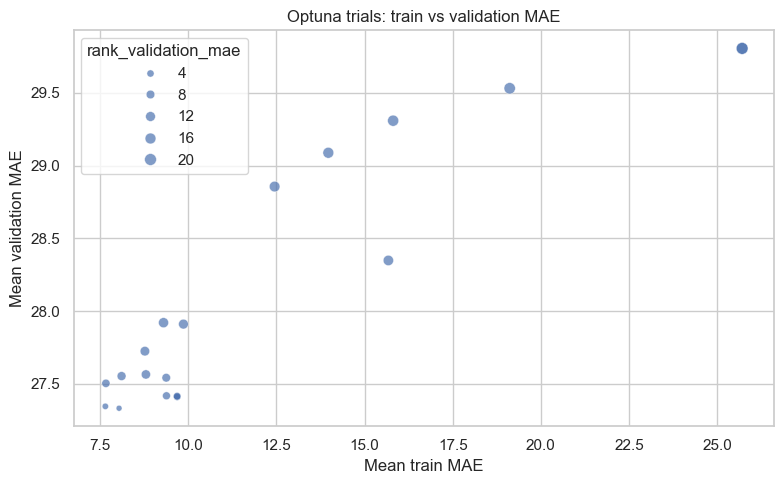

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=trials_df,
    x="mean_train_mae",
    y="mean_validation_mae",
    size="rank_validation_mae",
    alpha=0.7,
)
plt.title("Optuna trials: train vs validation MAE")
plt.xlabel("Mean train MAE")
plt.ylabel("Mean validation MAE")
plt.tight_layout()

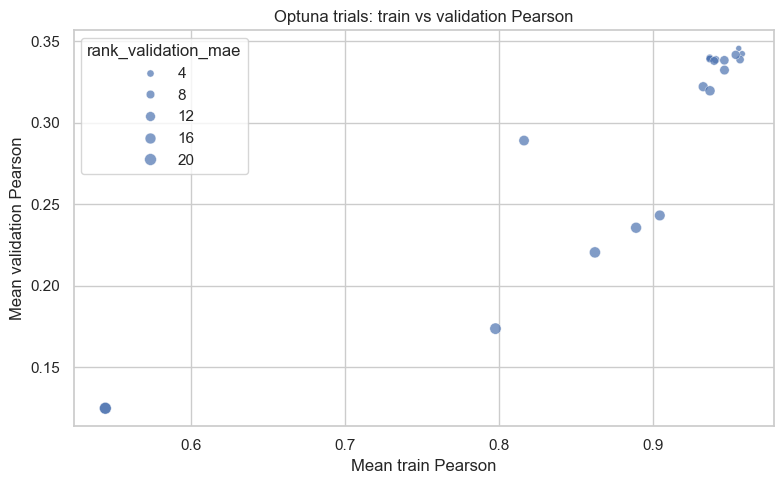

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=trials_df,
    x="mean_train_pearson",
    y="mean_validation_pearson",
    size="rank_validation_mae",
    alpha=0.7,
)
plt.title("Optuna trials: train vs validation Pearson")
plt.xlabel("Mean train Pearson")
plt.ylabel("Mean validation Pearson")
plt.tight_layout()

## Inner Validation Performance With Best Optuna Hyperparameters

After Optuna picks the best parameter set, we re-run grouped CV on the outer-train data using that tuned configuration. These folds are still validation-style results, not final test results.

In [10]:
tuned_config = RandomForestExperimentConfig(**asdict(config))
for key, value in best_params.items():
    setattr(tuned_config, key, value)

inner_cv_results = RandomForestCrossValidator(tuned_config).run_cv(X_train, y_train, groups_train)
inner_fold_results = inner_cv_results["fold_results"]
inner_summary = inner_cv_results["summary"]
inner_predictions = inner_cv_results["predictions"]

inner_fold_results

,fold,n_train,n_test,n_train_groups,n_test_groups,pearson,spearman,rmse,mae
0,1,17713,8388,36,10,0.531089,0.545111,27.714214,21.979910
1,2,17773,8328,36,12,0.321317,0.326436,35.067615,28.234842
2,3,17741,8360,36,11,0.184636,0.180883,39.101625,31.785147


In [11]:
inner_summary

,fold,n_train,n_test,n_train_groups,n_test_groups,pearson,spearman,rmse,mae
0,mean,17742.333333,8358.666667,36.0,11.0,0.345681,0.35081,33.961151,27.333299


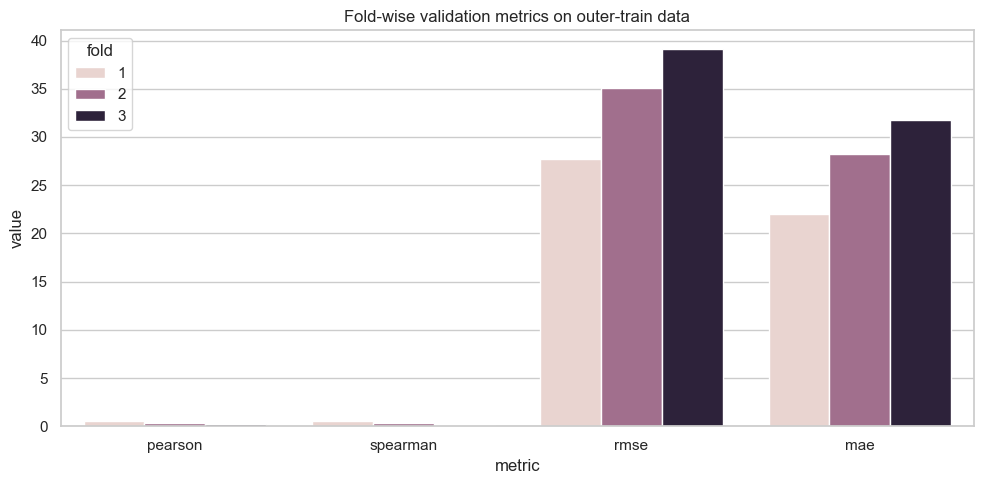

In [12]:
metric_columns = ["pearson", "spearman", "rmse", "mae"]
melted = inner_fold_results.melt(id_vars="fold", value_vars=metric_columns, var_name="metric", value_name="value")

plt.figure(figsize=(10, 5))
sns.barplot(data=melted, x="metric", y="value", hue="fold")
plt.title("Fold-wise validation metrics on outer-train data")
plt.tight_layout()

In [13]:
inner_predictions = inner_predictions.copy()
inner_predictions["residual"] = inner_predictions["y_true"] - inner_predictions["y_pred"]
inner_predictions["abs_error"] = inner_predictions["residual"].abs()
inner_predictions.head()

,fold,row_index,group,y_true,y_pred,residual,abs_error
0,1,3509,LPA,-1.2,30.217307,-31.417307,31.417307
1,1,3510,LPA,22.4,33.852885,-11.452885,11.452885
2,1,3511,LPA,29.2,35.867225,-6.667225,6.667225
3,1,3512,LPA,55.9,36.360941,19.539059,19.539059
4,1,3513,LPA,75.8,36.576204,39.223796,39.223796


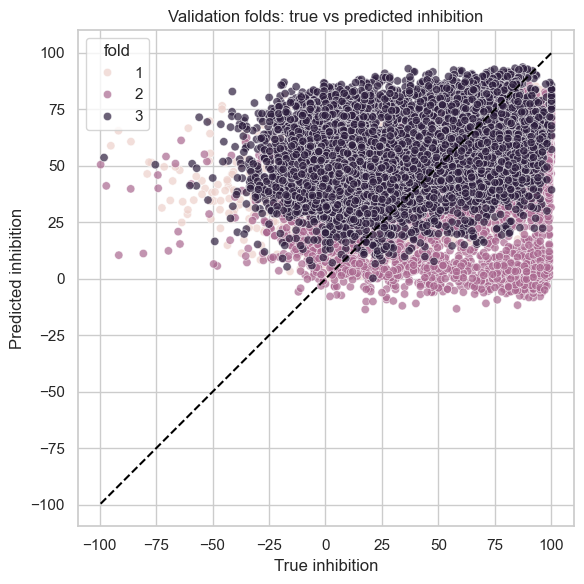

In [14]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=inner_predictions, x="y_true", y="y_pred", hue="fold", alpha=0.7)
line_min = min(inner_predictions["y_true"].min(), inner_predictions["y_pred"].min())
line_max = max(inner_predictions["y_true"].max(), inner_predictions["y_pred"].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
plt.title("Validation folds: true vs predicted inhibition")
plt.xlabel("True inhibition")
plt.ylabel("Predicted inhibition")
plt.tight_layout()

In [15]:
gene_validation_summary = inner_predictions.groupby("group").agg(
    n_samples=("y_true", "size"),
    y_true_mean=("y_true", "mean"),
    y_pred_mean=("y_pred", "mean"),
    mae=("abs_error", "mean"),
).sort_values("mae", ascending=False)
gene_validation_summary.head(20)

,n_samples,y_true_mean,y_pred_mean,mae
group,,,,
INHBE,3479,28.053935,60.833406,41.542709
AGT,4748,57.492624,39.536335,33.012187
PCSK9,2801,41.980196,48.974286,27.307953
MARC1,457,49.523851,48.398002,26.755228
ANGPTL3,465,51.339720,55.637319,26.419057
MMAC1,6,38.333333,57.308156,25.775158
APP,2320,47.428797,40.478980,25.557111
HSD17B13,6159,42.743916,48.059069,22.273232
FIREFLY LUC,107,71.372610,63.565295,22.269262


## Interpretation Notes

- `value` and `mean_validation_mae` in the Optuna table are inner validation losses, not final test results.
- Lower validation MAE is better.
- A large gap between `mean_train_mae` and `mean_validation_mae` suggests overfitting.
- Stable improvement across trials and inner folds is more meaningful than improvement on only one fold.
- This notebook stops before evaluating on the final outer test set, so it is safe to use these results to choose model settings.

## Optional Export

In [16]:
processed_dir = os.environ.get("CMSIRNA_PROCESSED_DIR")
if processed_dir:
    output_dir = Path(processed_dir)
    split_summary_path = output_dir / "rf_optuna_train_validation_split_summary.csv"
    trials_path = output_dir / "rf_optuna_trials.csv"
    inner_fold_results_path = output_dir / "rf_optuna_inner_fold_results.csv"
    inner_summary_path = output_dir / "rf_optuna_inner_summary.csv"
    inner_predictions_path = output_dir / "rf_optuna_inner_predictions.csv"
    split_summary.to_csv(split_summary_path, index=False)
    trials_df.to_csv(trials_path, index=False)
    inner_fold_results.to_csv(inner_fold_results_path, index=False)
    inner_summary.to_csv(inner_summary_path, index=False)
    inner_predictions.to_csv(inner_predictions_path, index=False)
    print("Saved split summary to:", split_summary_path)
    print("Saved trials to:", trials_path)
    print("Saved inner fold results to:", inner_fold_results_path)
    print("Saved inner summary to:", inner_summary_path)
    print("Saved inner predictions to:", inner_predictions_path)
else:
    print("CMSIRNA_PROCESSED_DIR is not set; skipping export.")

Saved split summary to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/rf_optuna_train_validation_split_summary.csv
Saved trials to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/rf_optuna_trials.csv
Saved inner fold results to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/rf_optuna_inner_fold_results.csv
Saved inner summary to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/rf_optuna_inner_summary.csv
Saved inner predictions to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/rf_optuna_inner_predictions.csv
